Mapping des orbites : {0: 'Deep Space', 1: 'GEO', 2: 'LEO', 3: 'SSO'}


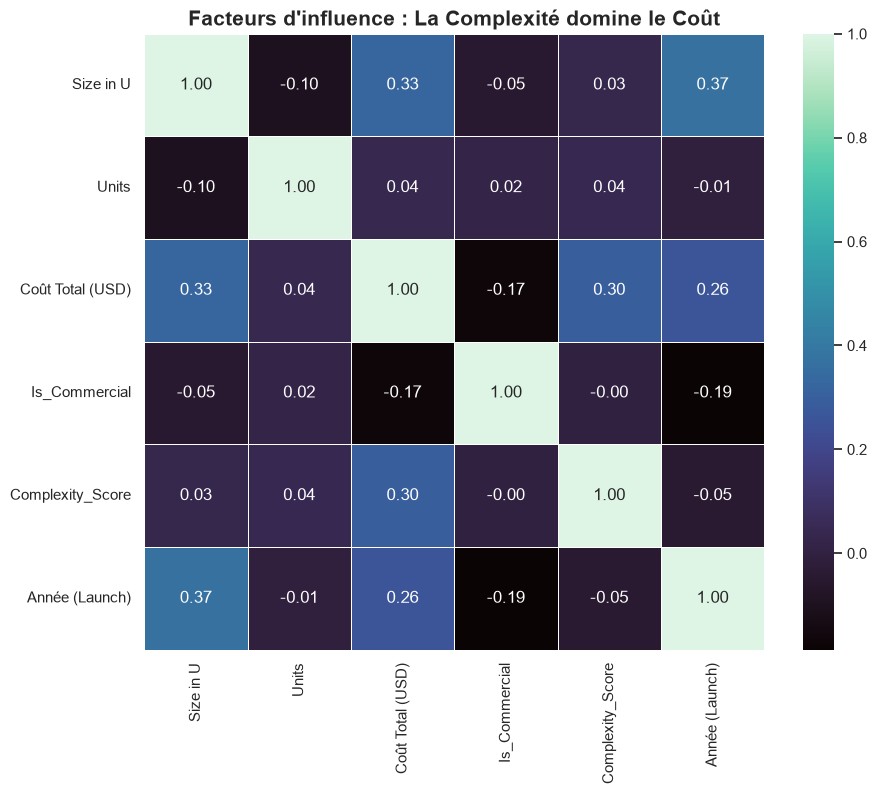

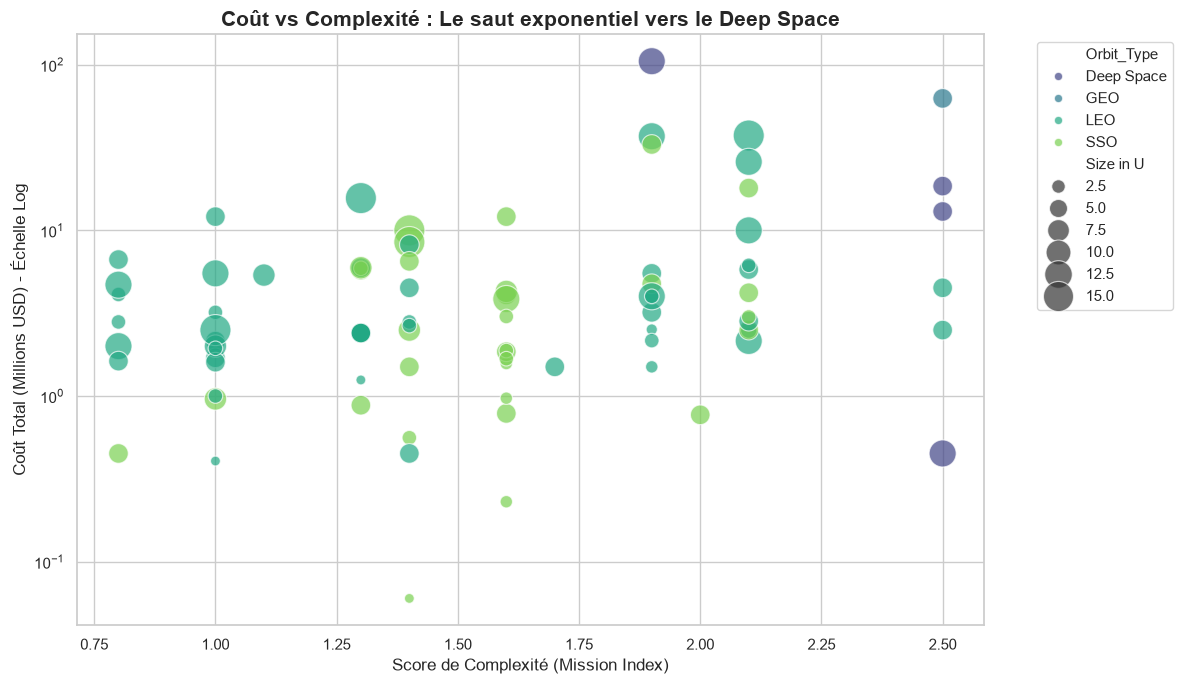

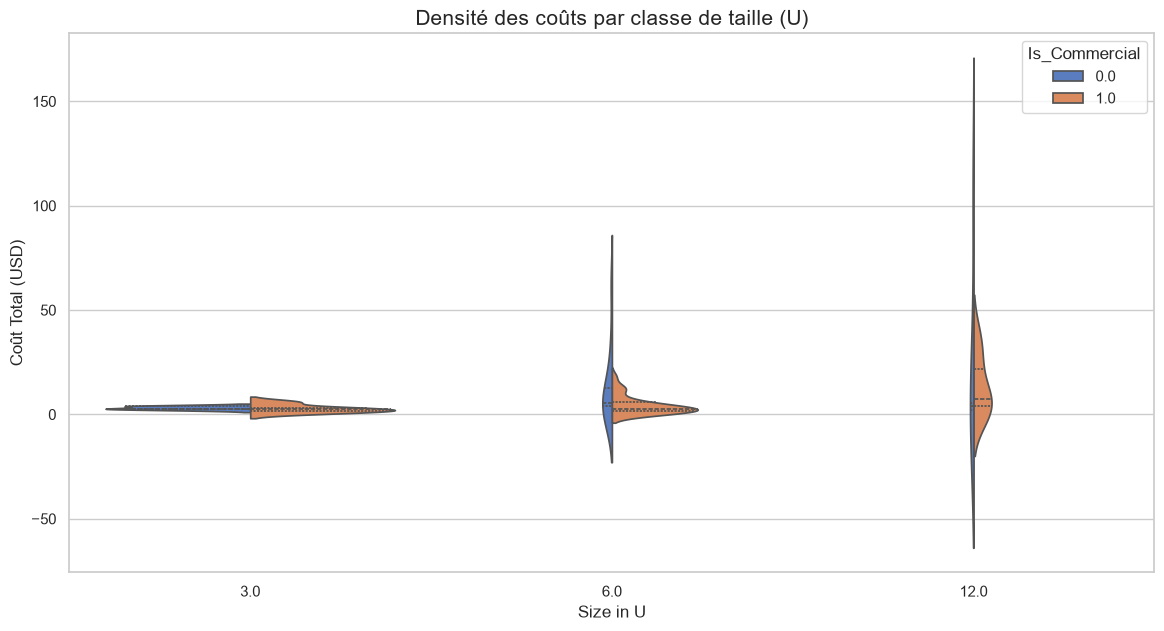

### Statistiques descriptives pour ton texte de poster :
|       |   Size in U |    Units |   Coût Total (USD) |   Is_Commercial |   Complexity_Score |   Année (Launch) |
|:------|------------:|---------:|-------------------:|----------------:|-------------------:|-----------------:|
| count |    88       | 88       |            88      |       88        |           88       |         88       |
| mean  |     6.44886 |  1.82955 |             7.1756 |        0.647727 |            1.55682 |       2022.15    |
| std   |     3.74246 |  2.00127 |            14.1629 |        0.480416 |            0.47411 |          2.62849 |
| min   |     1       |  1       |             0.06   |        0        |            0.8     |       2014       |
| 25%   |     3       |  1       |             1.8125 |        0        |            1.3     |       2020.75    |
| 50%   |     6       |  1       |             2.815  |        1        |            1.5     |       2023       |
| 75%   |     6.5     |  1     

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION VISUELLE ---
# On choisit un style blanc et quadrillé, parfait pour l'impression sur poster
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# --- 2. CHARGEMENT ET NETTOYAGE ---
file_path = "CubeSat_Dataset_Clean.csv"
df = pd.read_csv(file_path)

df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes

print(f"Mapping des orbites : {dict(enumerate(orbit_names))}")

# Nettoyage de la colonne Coût : on remplace la virgule par un point et on convertit en float
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)

# --- 3. GÉNÉRATION DE LA MATRICE DE CORRÉLATION ---
plt.figure(figsize=(10, 8))
# On ne garde que les colonnes numériques pour la corrélation
numeric_cols = ['Size in U', 'Units', 'Coût Total (USD)', 'Is_Commercial', 'Complexity_Score', 'Année (Launch)']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='mako', fmt=".2f", linewidths=0.5)
plt.title("Facteurs d'influence : La Complexité domine le Coût", fontsize=15, fontweight='bold')
plt.show()

# --- 4. SCATTER PLOT (LE PLAN KNN) ---
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='Complexity_Score', 
    y='Coût Total (USD)', 
    hue='Orbit_Type', 
    size='Size in U', 
    sizes=(50, 500), 
    alpha=0.7,
    palette="viridis"
)
plt.yscale('log') # Échelle log car les coûts varient de 0.06 à 105M$
plt.title("Coût vs Complexité : Le saut exponentiel vers le Deep Space", fontsize=15, fontweight='bold')
plt.xlabel("Score de Complexité (Mission Index)", fontsize=12)
plt.ylabel("Coût Total (Millions USD) - Échelle Log", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5. VIOLIN PLOT (DISTRIBUTION ET DENSITÉ) ---
plt.figure(figsize=(14, 7))
sns.violinplot(
    data=df[df['Size in U'].isin([3, 6, 12])], # On se concentre sur les tailles standards
    x='Size in U', 
    y='Coût Total (USD)', 
    hue='Is_Commercial', 
    split=True,     # Permet de comparer Commercial vs Institutionnel sur le même "violon"
    inner="quart",  # Affiche les quartiles à l'intérieur
    palette="muted"
)
plt.title("Densité des coûts par classe de taille (U)", fontsize=15)
plt.show()


# --- 6. EXPORT DES STATS POUR LE POSTER ---
print("### Statistiques descriptives pour ton texte de poster :")
print(df[numeric_cols].describe().to_markdown())

C:\Users\diego\AppData\Local\Temp\ipykernel_21616\395206661.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


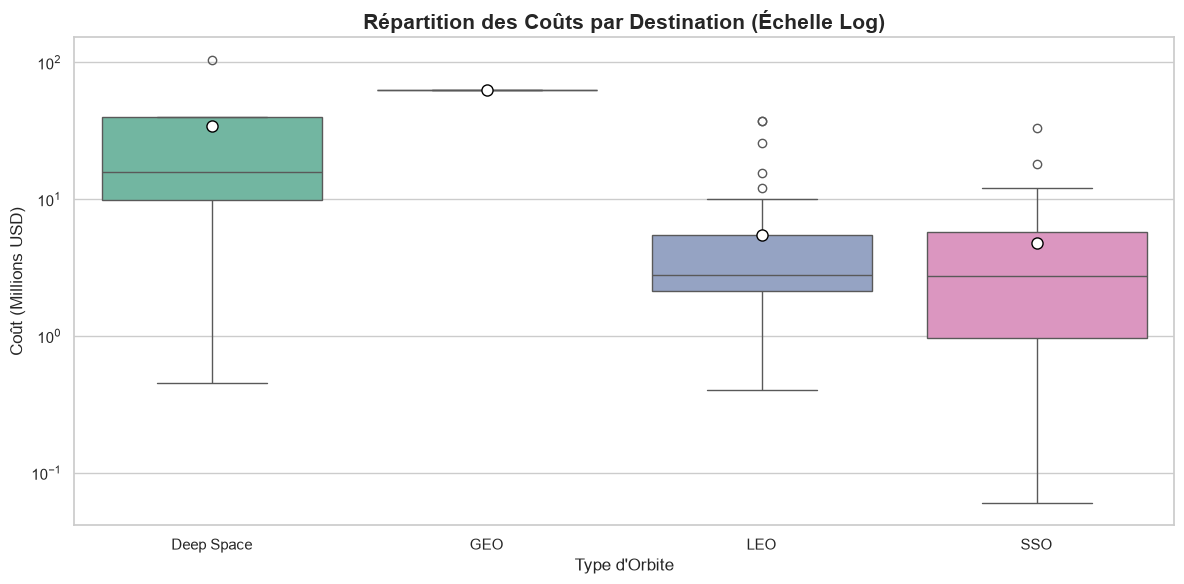

C:\Users\diego\AppData\Local\Temp\ipykernel_21616\395206661.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_complexity.index, y=avg_complexity.values, palette="mako")


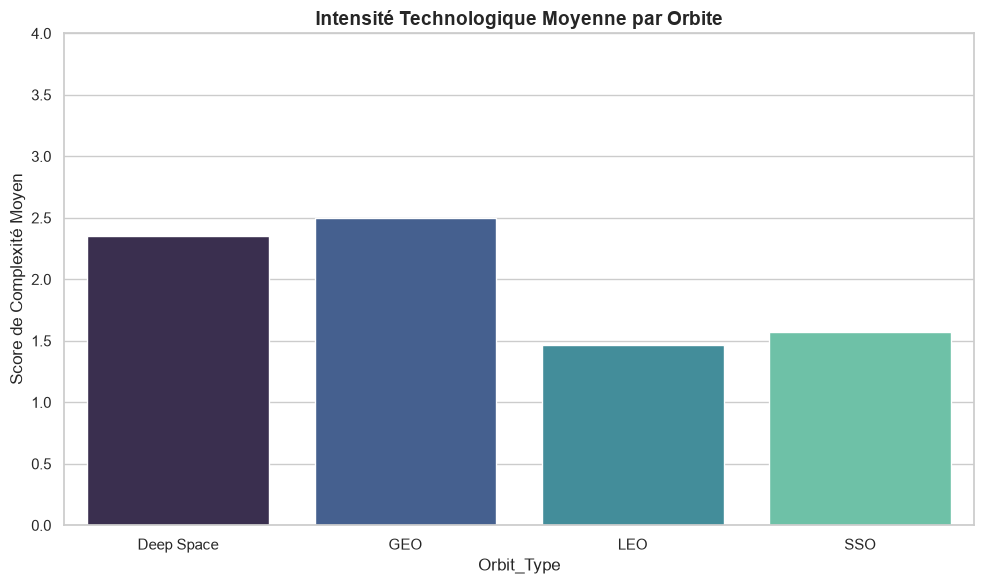

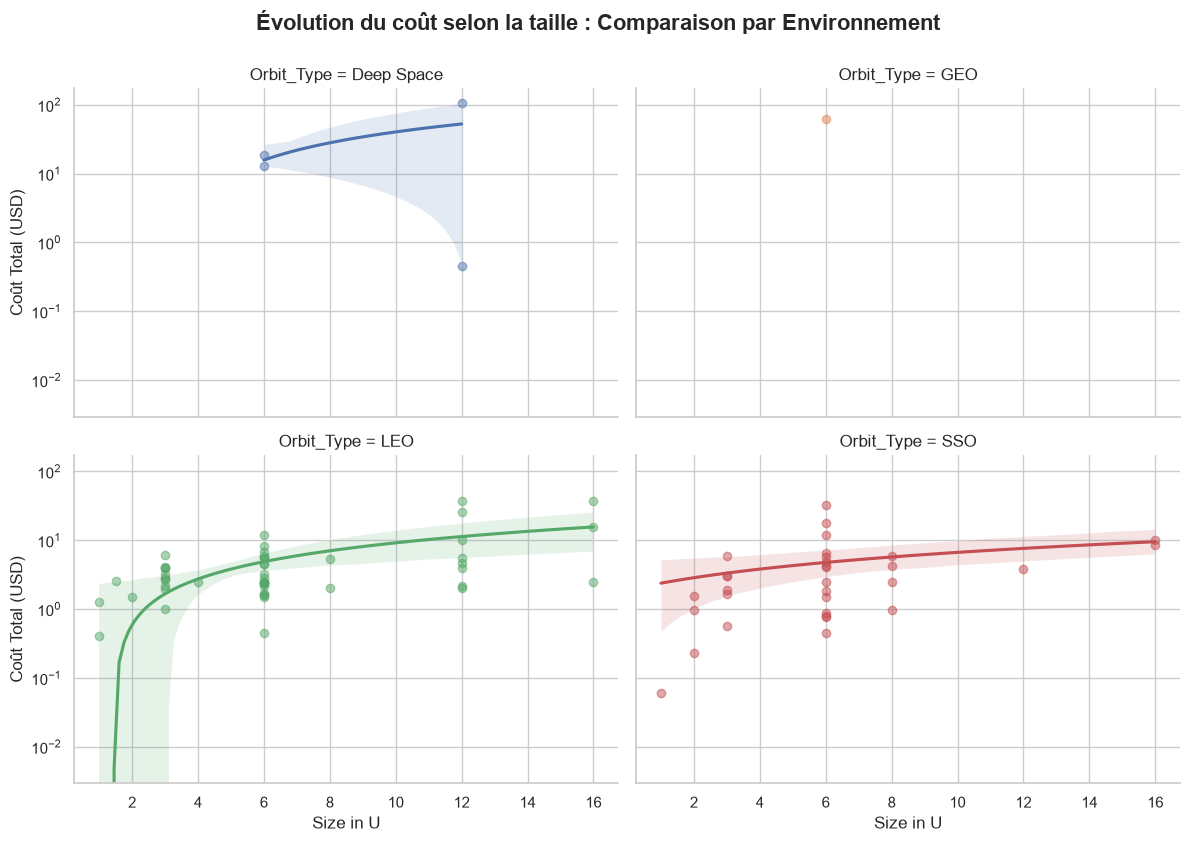

### Statistiques moyennes par type d'orbite :
| Orbit_Type   |   ('Coût Total (USD)', 'mean') |   ('Coût Total (USD)', 'median') |   ('Coût Total (USD)', 'count') |   ('Complexity_Score', 'mean') |
|:-------------|-------------------------------:|---------------------------------:|--------------------------------:|-------------------------------:|
| Deep Space   |                          34.24 |                            15.75 |                               4 |                           2.35 |
| GEO          |                          62.6  |                            62.6  |                               1 |                           2.5  |
| LEO          |                           5.49 |                             2.8  |                              51 |                           1.47 |
| SSO          |                           4.75 |                             2.75 |                              32 |                           1.57 |


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# --- 2. CHARGEMENT ET PRÉPARATION ---
file_path = "CubeSat_Dataset_Clean.csv"
df = pd.read_csv(file_path)

# Nettoyage et conversion
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)
df['Orbit_Type'] = df['Orbit_Type'].astype('category')

# --- 3. BOXPLOT : LA RÉALITÉ FINANCIÈRE DES ORBITES ---
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='Orbit_Type', 
    y='Coût Total (USD)', 
    palette="Set2",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
plt.yscale('log')
plt.title("Répartition des Coûts par Destination (Échelle Log)", fontsize=15, fontweight='bold')
plt.ylabel("Coût (Millions USD)")
plt.xlabel("Type d'Orbite")
plt.tight_layout()
plt.show()

# --- 4. BARPLOT : COMPLEXITÉ VS ORBITE ---
# Est-ce que les missions lointaines sont vraiment plus complexes ?
plt.figure(figsize=(10, 6))
avg_complexity = df.groupby('Orbit_Type')['Complexity_Score'].mean().sort_values()
sns.barplot(x=avg_complexity.index, y=avg_complexity.values, palette="mako")
plt.title("Intensité Technologique Moyenne par Orbite", fontsize=14, fontweight='bold')
plt.ylabel("Score de Complexité Moyen")
plt.ylim(0, 4) # On garde l'échelle de ton score
plt.tight_layout()
plt.show()

# --- 5. FACET GRID : TAILLE VS COÛT PAR ORBITE ---
# Pour voir si 1U en LEO coûte la même chose qu'un 1U en Deep Space
g = sns.FacetGrid(df, col="Orbit_Type", hue="Orbit_Type", col_wrap=2, height=4, aspect=1.5)
g.map(sns.regplot, "Size in U", "Coût Total (USD)", scatter_kws={'alpha':0.5})
g.set(yscale="log")
g.fig.suptitle("Évolution du coût selon la taille : Comparaison par Environnement", fontsize=16, fontweight='bold', y=1.05)
plt.show()

# --- 6. EXPORT DES STATS PAR ORBITE (Pour tes légendes) ---
print("### Statistiques moyennes par type d'orbite :")
orbit_stats = df.groupby('Orbit_Type').agg({
    'Coût Total (USD)': ['mean', 'median', 'count'],
    'Complexity_Score': 'mean'
}).round(2)
print(orbit_stats.to_markdown())

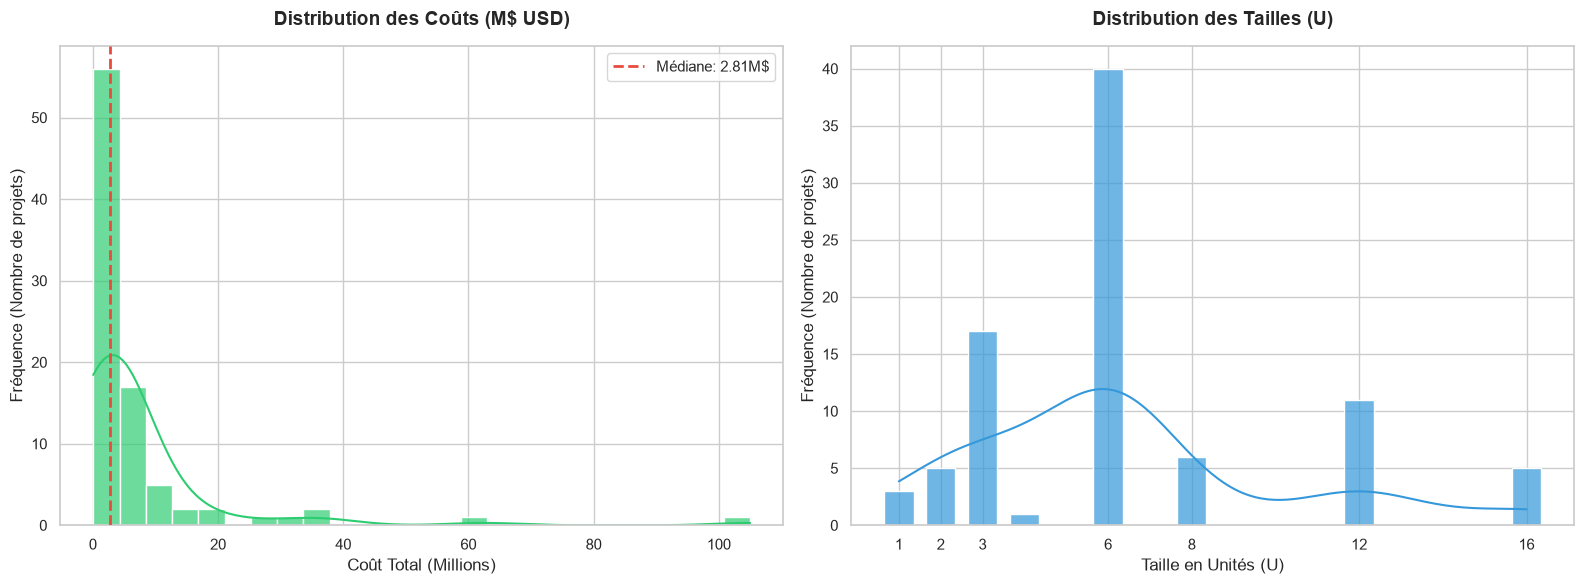

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid") # Grille propre en arrière-plan

# --- GAUCHE : Distribution des COÛTS (Vert Émeraude) ---
sns.histplot(df['Coût Total (USD)'], kde=True, color="#2ecc71", ax=ax1, bins=25, alpha=0.7)
ax1.set_title('Distribution des Coûts (M$ USD)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Coût Total (Millions)', fontsize=12)
ax1.set_ylabel('Fréquence (Nombre de projets)', fontsize=12)

# Ajout de la médiane en rouge
median_cost = df['Coût Total (USD)'].median()
ax1.axvline(median_cost, color='#e74c3c', linestyle='--', linewidth=2, label=f'Médiane: {median_cost:.2f}M$', zorder=3)
ax1.legend()

# --- DROITE : Distribution des TAILLES (Bleu Ciel) ---
# Note : discrete=True est crucial ici pour que les barres s'alignent sur 1, 2, 3, 6...
sns.histplot(df['Size in U'], color="#3498db", ax=ax2, discrete=True, shrink=0.7, kde=True, alpha=0.7)
ax2.set_title('Distribution des Tailles (U)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Taille en Unités (U)', fontsize=12)
ax2.set_ylabel('Fréquence (Nombre de projets)', fontsize=12)

# On force l'affichage des paliers standards des CubeSats
standard_units = [1, 2, 3, 6, 8, 12, 16]
ax2.set_xticks(standard_units)


# --- 3. Finition et Affichage ---
plt.tight_layout()

# Optionnel : Sauvegarde pour le poster (haute résolution)
# plt.savefig("distributions_cubesat_ESA.png", dpi=300, bbox_inches='tight')

plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_21616\135549562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Orbit_Type', y='Coût Total (USD)', palette="Set2", ax=ax2)


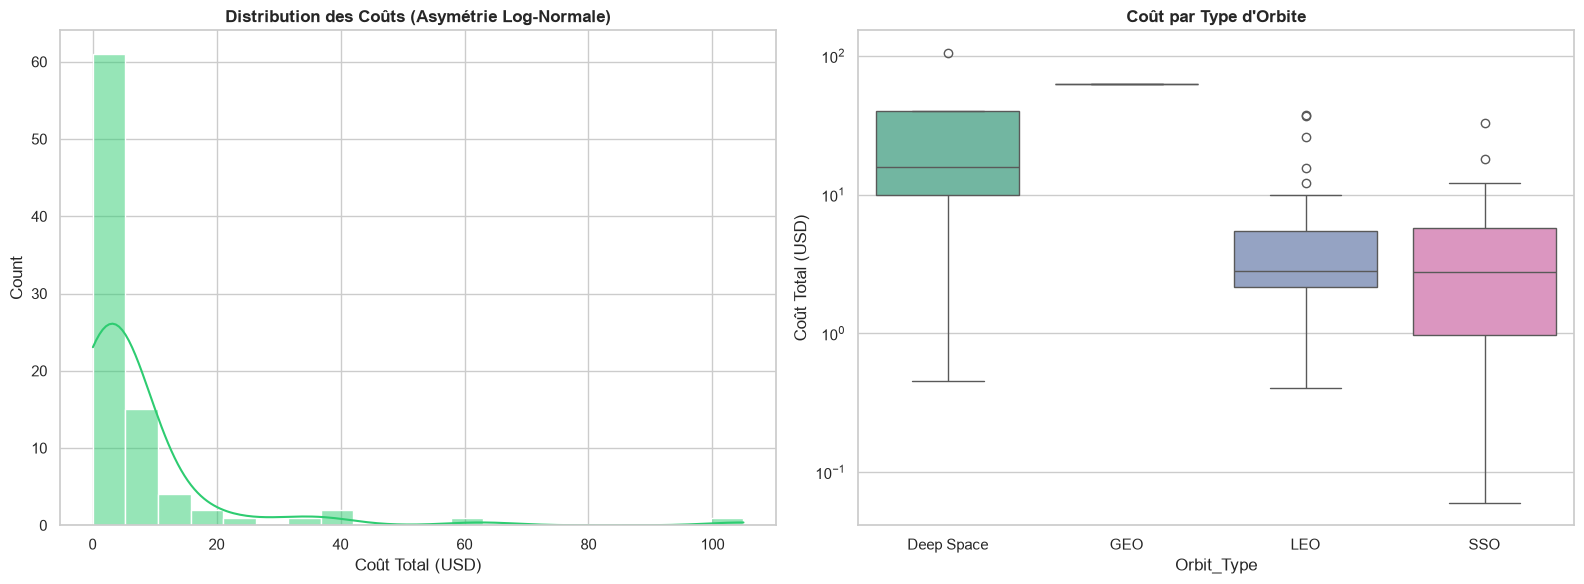

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['Coût Total (USD)'], kde=True, color="#2ecc71", ax=ax1, bins=20)
ax1.set_title('Distribution des Coûts (Asymétrie Log-Normale)', fontweight='bold')

sns.boxplot(data=df, x='Orbit_Type', y='Coût Total (USD)', palette="Set2", ax=ax2)
ax2.set_title('Coût par Type d\'Orbite', fontweight='bold')
ax2.set_yscale('log')
plt.tight_layout()
plt.show()

analyse

In [14]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az

# 1. Préparation des données
df = pd.read_csv("CubeSat_Dataset_Clean.csv")

# On centre l'année pour aider le modèle à converger (2024 = 0)
df['Year_Scaled'] = df['Année (Launch)'] - 2024
df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes
# Suppression de la ligne vide si nécessaire
df = df.dropna(subset=['Coût Total (USD)'])

n_orbits = len(orbit_names)
# 2. Construction du Modèle Bayésien
with pm.Model() as cubesat_model:
    # --- Priors (nos hypothèses de départ) ---
    alpha_orbit = pm.Normal("alpha_orbit", mu=0, sigma=1.5, shape=n_orbits)
    beta_size = pm.Normal("beta_size", mu=0.5, sigma=1)
    beta_complexity = pm.Normal("beta_complexity", mu=1, sigma=1) # On s'attend à un effet fort
    beta_comm = pm.Normal("beta_comm", mu=0, sigma=1)
    beta_year = pm.Normal("beta_year", mu=0, sigma=1)
    
    sigma = pm.HalfNormal("sigma", sigma=1) # Incertitude du modèle
    
    # --- Équation de la moyenne (Log-Link) ---
    mu = (alpha_orbit[df.orbit_idx.values] + 
          beta_size * df['Size in U'].values + 
          beta_complexity * df['Complexity_Score'].values +
          beta_comm * df['Is_Commercial'].values + 
          beta_year * df['Year_Scaled'].values)
    
    # --- Likelihood (La loi Log-Normale) ---
    y_obs = pm.LogNormal("y_obs", mu=mu, sigma=sigma, observed=df['Coût Total (USD)'].values)
    
    # --- Inférence (Le modèle "apprend") ---
    trace = pm.sample(2000, tune=1000, target_accept=0.95)

# 3. Visualisation des résultats


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_orbit, beta_size, beta_complexity, beta_comm, beta_year, sigma]


c:\Users\diego\miniconda3\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 28 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                   mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
alpha_orbit[0]    -0.13   0.68     -1.2     0.96      1736      2196  1.00   
alpha_orbit[1]     1.15   0.92     -0.3      2.6      2878      2993  1.00   
alpha_orbit[2]    -0.32   0.39    -0.93      0.3      1520      1816  1.00   
alpha_orbit[3]    -0.62   0.42     -1.3    0.038      1484      1671  1.00   
beta_size         0.113  0.031    0.063     0.16      1978      2243  1.00   
beta_complexity    0.69  0.213     0.35        1      1638      2122  1.00   
beta_comm        -0.149  0.224    -0.51     0.21      2884      2663  1.00   
beta_year         0.075  0.046   0.0031     0.15      2562      2913  1.00   
sigma             1.001  0.082     0.88      1.1      3099      2820  1.00   

                mcse_mean  mcse_sd  
alpha_orbit[0]      0.016    0.012  
alpha_orbit[1]      0.017    0.012  
alpha_orbit[2]       0.01   0.0077  
alpha_orbit[3]      0.011   0.0079  
beta_size          0.0007  0.00052

<Figure size 1000x600 with 0 Axes>

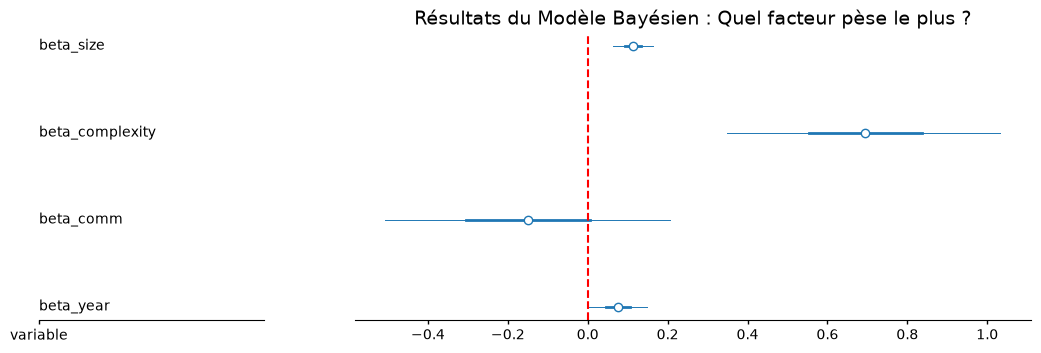

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
print(az.summary(trace))
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=["beta_size", "beta_complexity", "beta_comm", "beta_year"], combined=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Résultats du Modèle Bayésien : Quel facteur pèse le plus ?", fontsize=14)
plt.show()

<Figure size 1000x600 with 0 Axes>

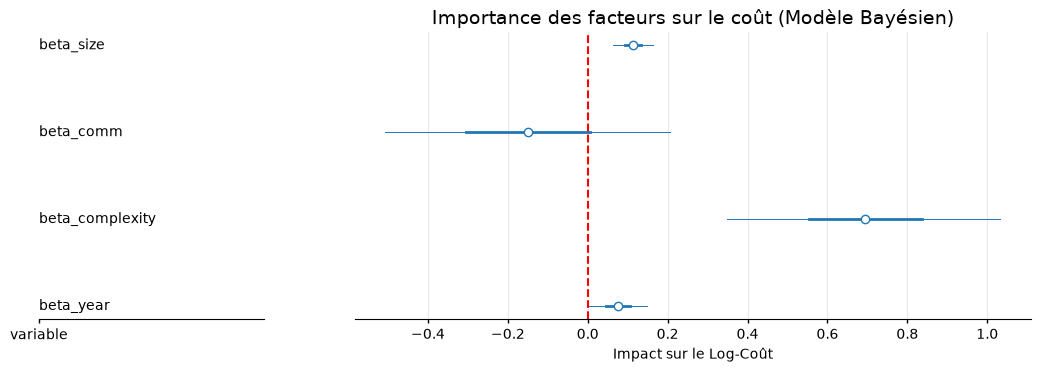

In [11]:
import arviz as az
import matplotlib.pyplot as plt

# On utilise les résultats que tu as obtenus
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=["beta_size", "beta_comm", "beta_complexity", "beta_year"], 
               combined=True, 
               )

plt.axvline(0, color='red', linestyle='--') # La ligne du "zéro" effet
plt.title("Importance des facteurs sur le coût (Modèle Bayésien)", fontsize=14)
plt.xlabel("Impact sur le Log-Coût")
plt.grid(axis='x', alpha=0.3)

# Sauvegarde pour le poster
# plt.savefig("bayes_forest_plot.png", dpi=300)
plt.show()

In [12]:
print(df.head())

   id               Project  Size in U  Units  Coût Total (USD)  \
0   0           AeroCube-15        3.0    1.0             4.100   
1   1  AISTECHSAT (DANU) 2U        2.0    1.0             0.230   
2   2                 Amber        6.0    2.0             5.750   
3   3         IOD Mission 3        6.0    4.0             2.145   
4   4              BlackCAT        6.0    1.0             5.800   

   Is_Commercial  Incl_Launch  Année (Launch)       Mission_Type  \
0            0.0          1.0          2022.0    Technology Demo   
1            1.0          0.0          2019.0  Earth Observation   
2            1.0          1.0          2024.0     Communications   
3            1.0          0.0          2023.0    Technology Demo   
4            1.0          0.0          2024.0  Science/Astronomy   

                                 Organization Manufactured (AIVT) by  \
0                       Aerospace Corporation               In-house   
1                                     Aistec

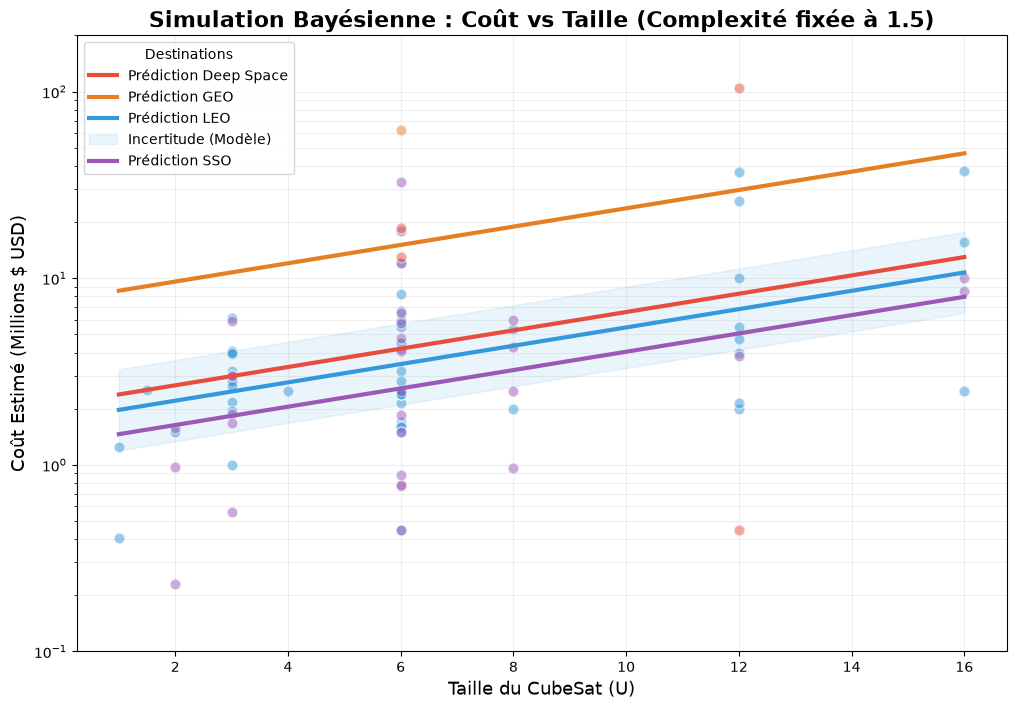

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Paramètres extraits de ton nouveau modèle ---
# Coefficients moyens (mean)
alphas = {
    "Deep Space": -0.13,
    "GEO": 1.15,
    "LEO": -0.32,
    "SSO": -0.62
}
b_size = 0.113
b_complexity = 0.69  # La grande nouveauté
b_comm = -0.149
sigma = 1.001

# --- 2. Fonction de prédiction ---
def predict_cubesat_cost(size, complexity, orbit_name, is_comm=1):
    alpha = alphas[orbit_name]
    # Equation : exp(alpha + b1*size + b2*complexity + b3*comm)
    log_mu = alpha + (b_size * size) + (b_complexity * complexity) + (b_comm * is_comm)
    return np.exp(log_mu)

# --- 3. Génération des données pour le graphique ---
sizes = np.linspace(1, 16, 100)
# On simule pour une complexité "standard" de 1.5
complexity_std = 1.5 

plt.figure(figsize=(12, 8))

# Calcul pour chaque orbite
colors = {"LEO": "#3498db", "SSO": "#9b59b6", "GEO": "#e67e22", "Deep Space": "#e74c3c"}

for orbit, alpha_val in alphas.items():
    costs = predict_cubesat_cost(sizes, complexity_std, orbit)
    plt.plot(sizes, costs, label=f'Prédiction {orbit}', color=colors[orbit], lw=3)
    
    # Ajout de l'ombre d'incertitude (HDI) pour le LEO à titre d'exemple
    if orbit == "LEO":
        lower = np.exp((alpha_val + b_size*sizes + b_complexity*complexity_std + b_comm*1) - 0.5*sigma)
        upper = np.exp((alpha_val + b_size*sizes + b_complexity*complexity_std + b_comm*1) + 0.5*sigma)
        plt.fill_between(sizes, lower, upper, color=colors[orbit], alpha=0.1, label='Incertitude (Modèle)')

# --- 4. Comparaison avec les données réelles ---
df = pd.read_csv("CubeSat_Dataset_Clean.csv")

# On affiche les points réels colorés par leur orbite
for orbit in df['Orbit_Type'].unique():
    subset = df[df['Orbit_Type'] == orbit]
    plt.scatter(subset['Size in U'], subset['Coût Total (USD)'], alpha=0.5, c=colors.get(orbit, 'grey'), s=60, edgecolors='w')

# --- 5. Cosmétique ---
plt.title(f"Simulation Bayésienne : Coût vs Taille (Complexité fixée à {complexity_std})", fontsize=16, fontweight='bold')
plt.xlabel("Taille du CubeSat (U)", fontsize=13)
plt.ylabel("Coût Estimé (Millions $ USD)", fontsize=13)
plt.yscale('log')
plt.ylim(0.1, 200)
plt.legend(title="Destinations", loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()